<a href="https://colab.research.google.com/github/MinThwMN/Retail-Store-Inventory-Forecasting/blob/main/XGBoost_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import os
import seaborn as sns

# ===============================
# 1. Load data + chuẩn bị folder
# ===============================
# Đọc file CSV từ Drive
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/retail_store_inventory.csv'
df = pd.read_csv(file_path, parse_dates=['Date'])
df = df.sort_values('Date') # Sắp xếp dữ liệu theo thời gian

os.makedirs("/content/drive/MyDrive/Colab Notebooks/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/preds", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/plots", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/report", exist_ok=True)

# Hiển thị dữ liệu
df.head()

Mounted at /content/drive


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


In [ ]:
# 2.Đọc file chưa dữ liệu
print("==== THÔNG TIN DỮ LIỆU ====")

df.info()

df.describe()


==== THÔNG TIN DỮ LIỆU ====
<class 'pandas.core.frame.DataFrame'>
Index: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  731

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [ ]:
# ===============================
# 2. Chuẩn hóa tên cột
# ===============================
df.columns = df.columns.str.strip().str.replace(" ", "_")
df['Date'] = pd.to_datetime(df['Date'])
from sklearn.preprocessing import LabelEncoder

# Xóa cột Demand_Forecast,Inventory_Level sau khi thực hiện lượt train đầu để so sánh
#df = df.drop(columns=["Demand_Forecast"])
# df = df.drop(columns=["Inventory_Level"])
print(df.head())

         Date Store_ID Product_ID     Category Region  Inventory_Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
72 2022-01-01     S004      P0013    Furniture   East              191   
71 2022-01-01     S004      P0012  Electronics  North              349   
70 2022-01-01     S004      P0011  Electronics   West              205   
69 2022-01-01     S004      P0010    Groceries   East              447   

    Units_Sold  Units_Ordered  Demand_Forecast  Price  Discount  \
0          127             55           135.47  33.50        20   
72          56             65            54.47  61.81         0   
71           9            165             0.95  14.25         5   
70          46             27            46.65  54.84         0   
69         104             96           115.03  33.48        15   

   Weather_Condition  Holiday/Promotion  Competitor_Pricing Seasonality  
0              Rainy                  0               29.69      Autumn  
72  

In [ ]:
# ===============================
# 3. Xử lý missing
# ===============================
df.fillna({"Price": df["Price"].median()}, inplace=True)

df.fillna({"Competitor":df["Competitor_Pricing"].median()}, inplace=True)

df.fillna({"Discount": 0}, inplace=True)

# Delete duplicate

df = df.drop_duplicates()



In [ ]:
# ===============================
# 4. Clip outlier UnitsSold (P1/P99)
# ===============================
p1, p99 = df["Units_Sold"].quantile([0.01,0.99])
df["Units_Sold"] = df["Units_Sold"].clip(p1,p99)


In [ ]:
# ===============================
# 5. One-hot Weather, Seasonality, Region, Category
# ===============================

# Đổi kiểu Store_ID
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Store_ID"] = le.fit_transform(df["Store_ID"])
df["Category"]=le.fit_transform(df["Category"])
cat_cols = ["Weather_Condition", "Seasonality", "Region"]

ohe = OneHotEncoder(sparse_output=False, drop='first')
cat_matrix = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_matrix.astype(int), columns=ohe.get_feature_names_out(cat_cols))
df = pd.concat([df.reset_index(drop=True), cat_df], axis=1)
df.drop(columns=cat_cols, inplace=True)

# Ép kiểu
for c in df.columns:
    if df[c].dtype == 'bool':
        df[c] = df[c].astype(int)



In [ ]:
df.head()

,Date,Store_ID,Product_ID,Category,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,...,Competitor_Pricing,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Region_North,Region_South,Region_West
0,2022-01-01,0,P0001,3,231,127,55,135.47,33.50,20,...,29.69,1,0,0,0,0,0,1,0,0
1,2022-01-01,3,P0013,2,191,56,65,54.47,61.81,0,...,63.92,0,0,1,0,0,0,0,0,0
2,2022-01-01,3,P0012,1,349,9,165,0.95,14.25,5,...,18.56,1,0,0,1,0,0,1,0,0
3,2022-01-01,3,P0011,1,205,46,27,46.65,54.84,0,...,57.76,0,0,1,1,0,0,0,0,1
4,2022-01-01,3,P0010,3,447,104,96,115.03,33.48,15,...,37.15,0,0,0,0,1,0,0,0,0


In [ ]:
# ===============================
# 6. MinMax cho Price, CompetitorPricing, Discount
# ===============================
scaler = MinMaxScaler()
num_cols = ["Price", "Competitor_Pricing", "Discount"]
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
#Kiểm tra dữ liệu

df.head()

,Date,Store_ID,Product_ID,Category,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,...,Competitor_Pricing,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Region_North,Region_South,Region_West
0,2022-01-01,0,P0001,3,231,127,55,135.47,33.50,20,...,29.69,1,0,0,0,0,0,1,0,0
1,2022-01-01,3,P0013,2,191,56,65,54.47,61.81,0,...,63.92,0,0,1,0,0,0,0,0,0
2,2022-01-01,3,P0012,1,349,9,165,0.95,14.25,5,...,18.56,1,0,0,1,0,0,1,0,0
3,2022-01-01,3,P0011,1,205,46,27,46.65,54.84,0,...,57.76,0,0,1,1,0,0,0,0,1
4,2022-01-01,3,P0010,3,447,104,96,115.03,33.48,15,...,37.15,0,0,0,0,1,0,0,0,0


In [ ]:

# ===============================
# 7. Feature Engineering (Lag, Rolling, Calendar, Interaction)
# ===============================
lags = [1, 7, 14, 28]
windows = [7, 14, 28]

In [ ]:
# Lag
for lag in lags:
    df[f"Units_Sold_lag_{lag}"] = df.groupby("Product_ID")["Units_Sold"].shift(lag)

# Rolling
for w in windows:
    df[f"UnitsSold_roll_mean_{w}"] = df.groupby("Product_ID")["Units_Sold"].shift(1).rolling(w).mean()
    df[f"UnitsSold_roll_std_{w}"] = df.groupby("Product_ID")["Units_Sold"].shift(1).rolling(w).std()
    df[f"UnitsSold_roll_max_{w}"] = df.groupby("Product_ID")["Units_Sold"].shift(1).rolling(w).max()
    df[f"UnitsSold_roll_min_{w}"] = df.groupby("Product_ID")["Units_Sold"].shift(1).rolling(w).min()

In [ ]:
# Calendar
df["dow"] = df["Date"].dt.dayofweek
df["week"] = df["Date"].dt.isocalendar().week.astype(int)
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["is_weekend"] = (df["dow"].isin([5, 6])).astype(int)
df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

In [ ]:
# Interaction
df["Price_Discount"] = df["Price"] * df["Discount"]
df["Price_CompDiff"] = df["Price"] - df["Competitor_Pricing"]

In [ ]:

# ===============================
# 8. Drop NaN do lag/rolling
# ===============================
df = df.sort_values("Date").dropna().reset_index(drop=True)

In [ ]:
# Block CV theo tuần

def week_block_cv(dates, n_splits=5):
    weeks = dates.dt.isocalendar().week.astype(int).unique()
    weeks = sorted(weeks)

    splits = []
    step = max(2, len(weeks) // (n_splits + 1))  # ≥ 2 tuần

    for i in range(n_splits):
        test_weeks = weeks[i * step : (i + 1) * step]
        if len(test_weeks) < 2:
            continue

        test_idx = dates.dt.isocalendar().week.astype(int).isin(test_weeks)
        test_idx = np.where(test_idx)[0]
        train_idx = np.where(~np.isin(np.arange(len(dates)), test_idx))[0]

        splits.append((train_idx, test_idx))

    return splits


In [ ]:

# ===============================
# Hyperparameter search space
# ===============================
param_grid = {
    'n_estimators': [500, 800, 1200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'reg_alpha': [0, 1e-3, 1e-2],
    'reg_lambda': [1, 3, 5],
    'min_child_weight': [1, 3]
}

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# ===============================
# Train theo Product_ID
# ===============================
models_product = {}
pred_dfs = {}
metrics_product = {}

for pid in df["Product_ID"].unique():

    df_pid = df[df["Product_ID"] == pid].sort_values("Date").reset_index(drop=True)
    if len(df_pid) < 30:
        continue

    features = [c for c in df_pid.columns if c not in ["Date", "Units_Sold", "Product_ID", "Category"]]
    X = df_pid[features].reset_index(drop=True)
    y = df_pid["Units_Sold"].reset_index(drop=True)

    splits = week_block_cv(df_pid["Date"], n_splits=5)
    if len(splits) == 0:
        continue

    rmse_folds = []
    wape_folds = []
    all_preds = []

    # ===============================
    # Block CV theo tuần
    # ===============================
    for train_idx, val_idx in splits:
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="rmse",
            early_stopping_rounds=50,
            random_state=42
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        y_pred = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        wape = np.sum(np.abs(y_val - y_pred)) / np.sum(np.abs(y_val)) * 100

        rmse_folds.append(rmse)
        wape_folds.append(wape)

        all_preds.append(pd.DataFrame({
            "Date": df_pid.loc[val_idx, "Date"],
            "Actual": y_val.values,
            "Predicted": y_pred
        }))

    # ===============================
    # Train final model (full Product_ID)
    # ===============================
    final_model = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        eval_metric="rmse",
        early_stopping_rounds=50,
        random_state=42
    )

    # dùng 14 ngày cuối đúng logic cũ
    horizon = 14
    cutoff = df_pid["Date"].max() - pd.Timedelta(days=horizon)
    train_final = df_pid[df_pid["Date"] < cutoff]
    val_final   = df_pid[df_pid["Date"] >= cutoff]

    X_tr = train_final[features]
    y_tr = train_final["Units_Sold"]
    X_va = val_final[features]
    y_va = val_final["Units_Sold"]

    final_model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    models_product[pid] = final_model
    pred_dfs[pid] = pd.concat(all_preds).sort_values("Date")

    metrics_product[pid] = {
        "CV_RMSE": np.mean(rmse_folds),
        "CV_WAPE (%)": np.mean(wape_folds),
        "n_samples": len(df_pid)
    }

    print(
        f"Product_ID={pid} | "
        f"RMSE={metrics_product[pid]['CV_RMSE']:.3f} | "
        f"WAPE={metrics_product[pid]['CV_WAPE (%)']:.2f}%"
    )


# ===============================
# Tổng hợp metrics
# ===============================
metrics_df = pd.DataFrame.from_dict(metrics_product, orient="index")
print(metrics_df.sort_values("CV_WAPE (%)"))




Product_ID=P0009 | RMSE=11.100 | WAPE=6.63%
Product_ID=P0002 | RMSE=11.152 | WAPE=6.72%
Product_ID=P0003 | RMSE=11.114 | WAPE=6.67%
Product_ID=P0001 | RMSE=11.127 | WAPE=6.68%
Product_ID=P0016 | RMSE=11.133 | WAPE=6.53%
Product_ID=P0013 | RMSE=10.902 | WAPE=6.46%
Product_ID=P0014 | RMSE=11.579 | WAPE=6.77%
Product_ID=P0015 | RMSE=10.976 | WAPE=6.43%
Product_ID=P0017 | RMSE=11.001 | WAPE=6.70%
Product_ID=P0018 | RMSE=11.020 | WAPE=6.52%
Product_ID=P0019 | RMSE=11.231 | WAPE=6.74%
Product_ID=P0020 | RMSE=11.306 | WAPE=6.66%
Product_ID=P0011 | RMSE=11.395 | WAPE=6.73%
Product_ID=P0012 | RMSE=11.075 | WAPE=6.69%
Product_ID=P0010 | RMSE=11.145 | WAPE=6.61%
Product_ID=P0005 | RMSE=11.052 | WAPE=6.53%
Product_ID=P0006 | RMSE=10.864 | WAPE=6.46%
Product_ID=P0007 | RMSE=11.671 | WAPE=6.85%
Product_ID=P0008 | RMSE=10.978 | WAPE=6.67%
Product_ID=P0004 | RMSE=11.666 | WAPE=6.99%
         CV_RMSE  CV_WAPE (%)  n_samples
P0015  10.975804     6.427533       3627
P0013  10.902217     6.460368       36

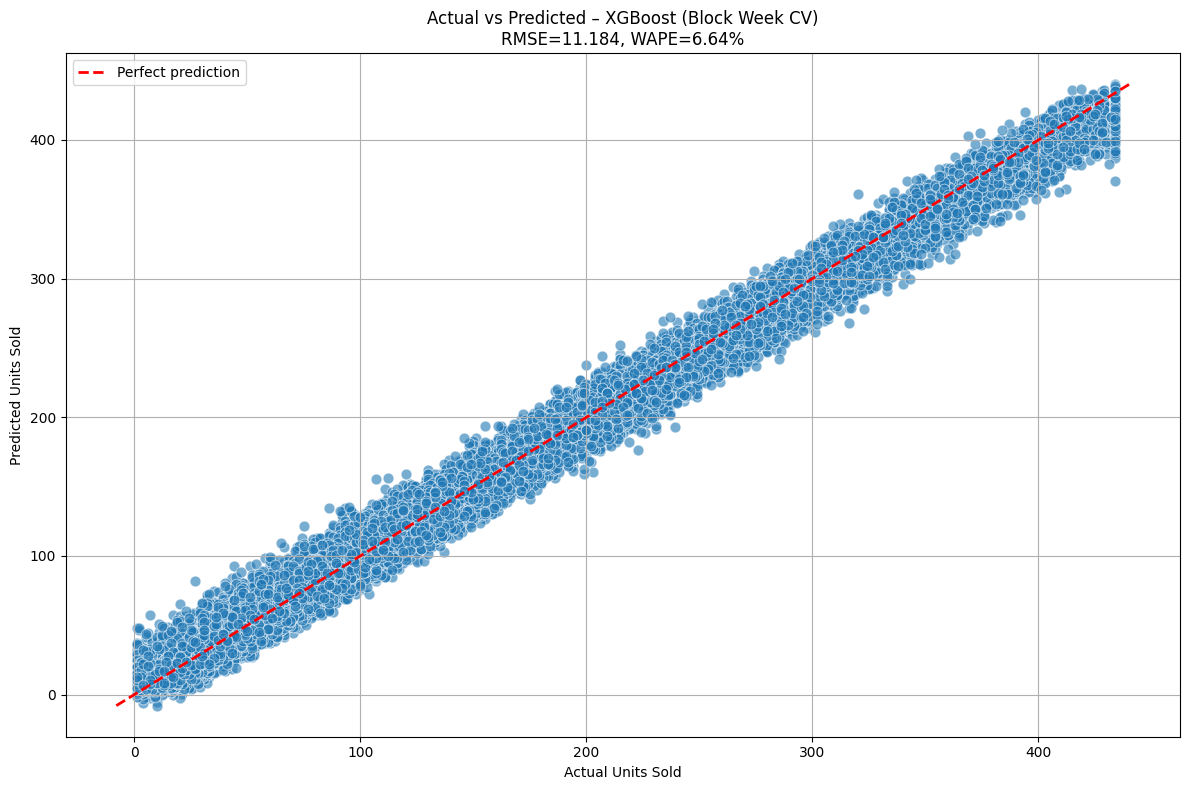

In [ ]:
# =========================
# Plot Actual vs Predicted (XGBoost – Block CV)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Gộp prediction từ XGBoost block-CV (theo Product_ID)
all_preds = pd.concat(pred_dfs.values(), ignore_index=True)

# Global RMSE & WAPE
rmse = np.sqrt(np.mean((all_preds["Actual"] - all_preds["Predicted"]) ** 2))
wape = (
    np.sum(np.abs(all_preds["Actual"] - all_preds["Predicted"]))
    / np.sum(np.abs(all_preds["Actual"]))
) * 100

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=all_preds,
    x="Actual",
    y="Predicted",
    alpha=0.6,
    s=60
)

min_val = min(all_preds["Actual"].min(), all_preds["Predicted"].min())
max_val = max(all_preds["Actual"].max(), all_preds["Predicted"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Perfect prediction"
)

plt.title(f"Actual vs Predicted – XGBoost (Block Week CV)\nRMSE={rmse:.3f}, WAPE={wape:.2f}%")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:
import json
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

# ===============================
# Drift check giữa train và validation (Product_ID)
# ===============================

all_X_train_list = []
all_X_val_list = []

for pid in models_product.keys():

    df_pid = df[df["Product_ID"] == pid].sort_values("Date").reset_index(drop=True)
    if len(df_pid) < 30:
        continue

    horizon = 14
    cutoff = df_pid["Date"].max() - pd.Timedelta(days=horizon)

    train = df_pid[df_pid["Date"] < cutoff]
    val   = df_pid[df_pid["Date"] >= cutoff]

    features = [
        c for c in train.columns
        if c not in ["Date", "Units_Sold", "Product_ID", "Category", "Region"]
    ]

    X_train = train[features]
    X_val   = val[features]

    all_X_train_list.append(X_train)
    all_X_val_list.append(X_val)

# ===============================
# KS drift test (toàn hệ thống)
# ===============================
drift_report = {}
drift_flags = []

if all_X_train_list and all_X_val_list:

    full_X_train = pd.concat(all_X_train_list, axis=0)
    full_X_val   = pd.concat(all_X_val_list, axis=0)

    numeric_feats = full_X_train.select_dtypes(include=[np.number]).columns.tolist()

    for feat in numeric_feats:

        train_vals = full_X_train[feat].dropna().values
        val_vals   = full_X_val[feat].dropna().values

        if len(train_vals) < 20 or len(val_vals) < 20:
            continue

        stat, pvalue = ks_2samp(train_vals, val_vals)

        drift_report[feat] = {
            "ks_stat": float(stat),
            "pvalue": float(pvalue),
            "train_mean": float(np.mean(train_vals)),
            "val_mean": float(np.mean(val_vals))
        }

        if pvalue < 0.01:
            drift_flags.append(feat)

    # Save report
    with open(
        "/content/drive/MyDrive/Colab Notebooks/report/drift_report.json",
        "w"
    ) as f:
        json.dump(drift_report, f, indent=2)

    print("Các biến bị drift (Product-level, toàn hệ thống):")
    print(drift_flags if drift_flags else "Không phát hiện drift đáng kể")

else:
    print("Không có dữ liệu để check drift.")


Các biến bị drift (Product-level, toàn hệ thống):
['UnitsSold_roll_std_7', 'UnitsSold_roll_max_7', 'UnitsSold_roll_mean_14', 'UnitsSold_roll_std_14', 'UnitsSold_roll_max_14', 'UnitsSold_roll_min_14', 'UnitsSold_roll_mean_28', 'UnitsSold_roll_std_28', 'UnitsSold_roll_max_28', 'UnitsSold_roll_min_28', 'dow', 'week', 'month', 'quarter']


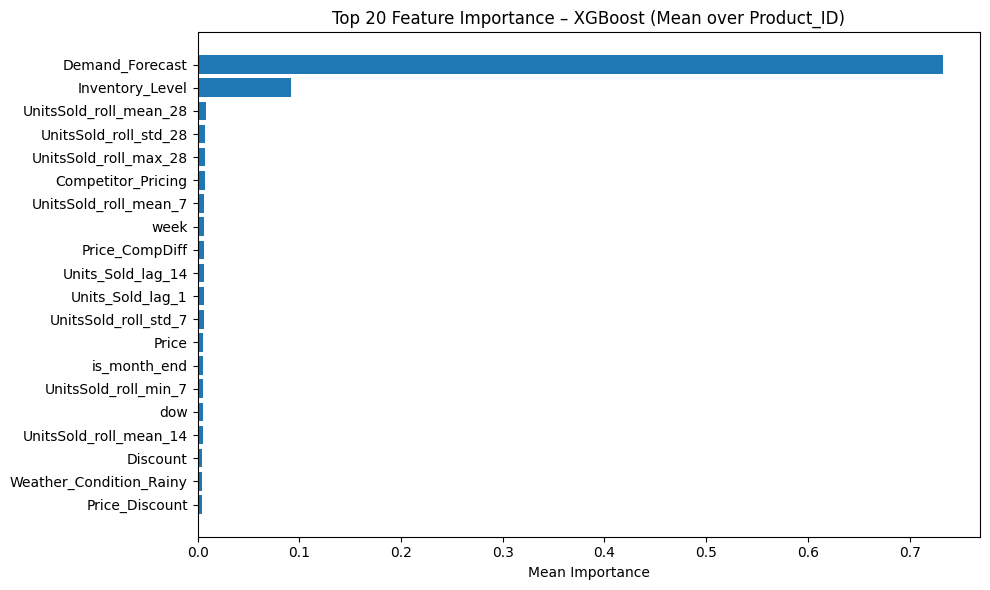

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fi_list = []

for pid, model in models_product.items():
    fi_list.append(model.feature_importances_)

mean_importance = np.mean(fi_list, axis=0)

feature_names = list(models_product.values())[0].get_booster().feature_names

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi_df["Feature"][:20][::-1], fi_df["Importance"][:20][::-1])
plt.title("Top 20 Feature Importance – XGBoost (Mean over Product_ID)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()


In [ ]:
# ===============================
# 14. Lưu model, dự đoán, feature list
# ===============================

# Lưu model
for cat, model in models_product.items():
    model.save_model(
        f"/content/drive/MyDrive/Colab Notebooks/models/xgb_{cat}.json"
    )

print(f"Đã lưu {len(models_product)} model XGBoost, mỗi Category một file.")

# ==================================================
# Lưu dự đoán validation theo
# ==================================================

pred_dir = "/content/drive/MyDrive/Colab Notebooks/preds/by_sku/"
os.makedirs(pred_dir, exist_ok=True)

for sku, df_pred in pred_dfs.items():

    df_pred = df_pred.sort_values("Date")

    df_pred.to_csv(
        f"{pred_dir}/xgb_val_pred_sku_{sku}.csv",
        index=False
    )

print(f"Đã lưu prediction cho {len(pred_dfs)} SKU.")

# ==================================================
# Lưu danh sách feature đã dùng (theo cột gốc)
# ==================================================

original_features = [
    c for c in df.columns
    if c not in ["Date", "Units_Sold", "Product_ID", "Category", "Region"]
]

with open(
    "/content/drive/MyDrive/Colab Notebooks/report/XGB_feature_list.md", "w"
) as f:
    for feat in original_features:
        f.write(f"- {feat}\n")

print("Đã lưu: model, prediction theo Product_ID, danh sách feature.")




Đã lưu 20 model XGBoost, mỗi Category một file.
Đã lưu prediction cho 20 SKU.
Đã lưu: model, prediction theo Product_ID, danh sách feature.


In [ ]:
# LẤY FILE .HTML
# !jupyter nbconvert --to html "dán_đường_dẫn_vừa_copy_tại_đây"
# dán_đường_dẫn_vừa_copy_tại_đây: TÌM CHỖ CHỨA FILE NÀY RỒI COPY ĐƯỜNG DẪN
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/XGBoost Regressor.ipynb"


[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/XGBoost Regressor.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 891502 bytes to /content/drive/MyDrive/Colab Notebooks/XGBoost Regressor.html
